In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                           classification_report, roc_curve, auc,
                           precision_recall_curve, RocCurveDisplay)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [3]:
df_credito = pd.read_csv('aprobacion_credito.csv')

In [5]:
df_credito.head()

,ingreso,edad,deuda_ingreso,score_credito,aprobado
0,59934.283060,61,0.241943,700.168505,1
1,47234.713977,66,0.119723,653.249986,0
2,62953.770762,57,0.167878,730.559383,1
3,80460.597128,28,0.566485,657.541774,0
4,45316.932506,20,0.190516,547.507193,0


In [7]:
df_credito.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ingreso        1000 non-null   float64
 1   edad           1000 non-null   int64  
 2   deuda_ingreso  1000 non-null   float64
 3   score_credito  1000 non-null   float64
 4   aprobado       1000 non-null   int64  
dtypes: float64(3), int64(2)
memory usage: 39.2 KB


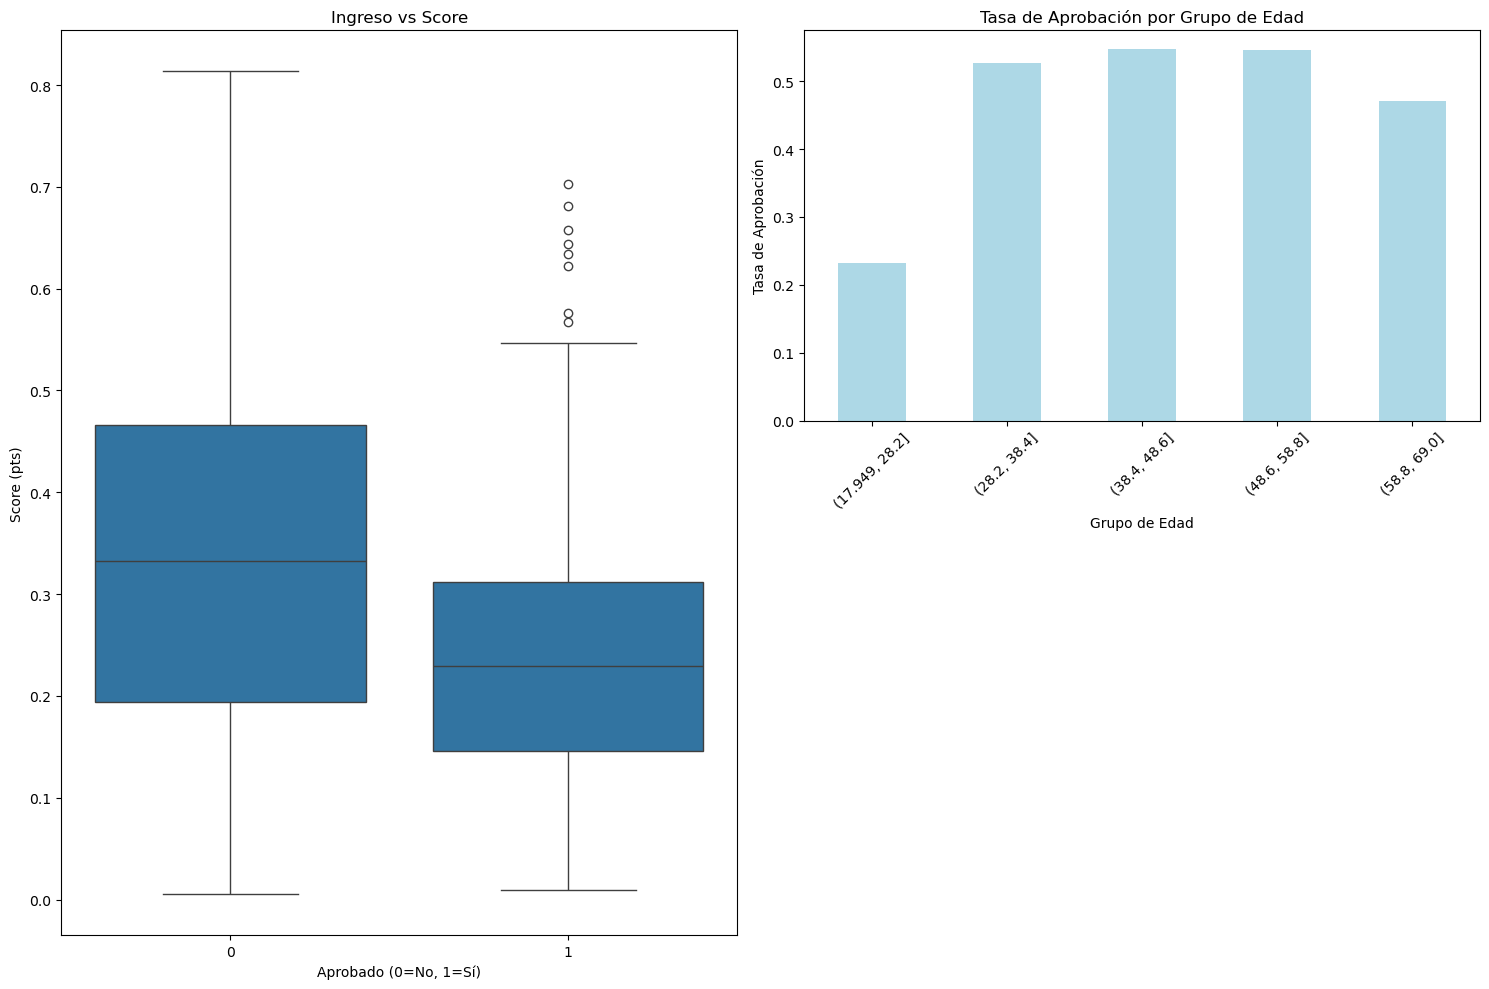

In [10]:
plt.figure(figsize=(15, 10))

plt.subplot(1, 2, 1)
sns.boxplot(x='aprobado', y='deuda_ingreso', data=df_credito)
plt.title('Ingreso vs Score')
plt.xlabel('Aprobado (0=No, 1=Sí)')
plt.ylabel('Score (pts)')

plt.subplot(2, 2, 2)
df_credito['edad_grupo'] = pd.cut(df_credito['edad'], bins=5)
aprobacion_por_edad = df_credito.groupby('edad_grupo')['aprobado'].mean()
aprobacion_por_edad.plot(kind='bar', color='lightblue')
plt.title('Tasa de Aprobación por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Tasa de Aprobación')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [13]:
df_credito.drop(columns = ['edad_grupo'], inplace = True)

Text(0.5, 1.0, 'Matriz de Correlación')

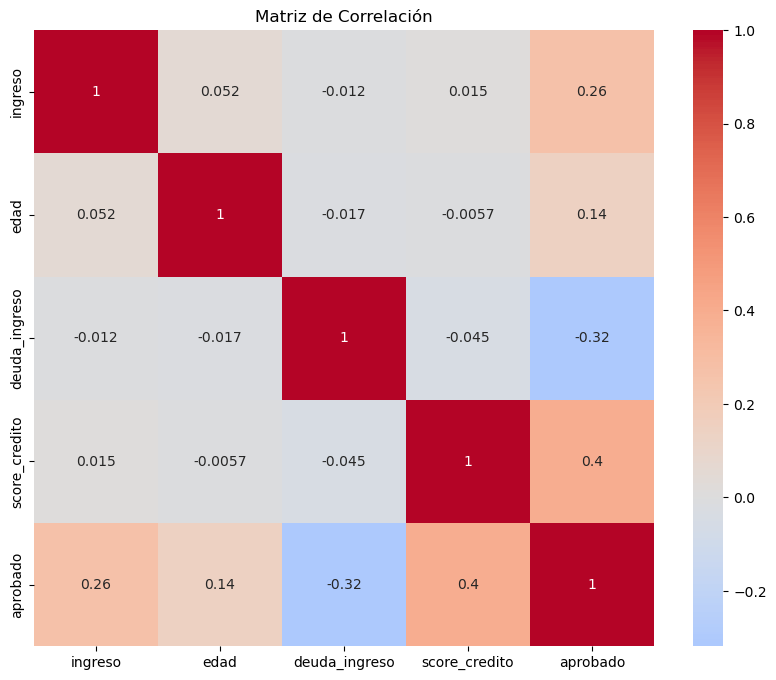

In [14]:
plt.figure(figsize=(10, 8))

correlation_matrix = df_credito.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')

### Modelo

In [15]:
X = df_credito.drop('aprobado', axis = 1)
y = df_credito['aprobado']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [19]:
pipeline_regression = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(random_state = 42))
])

pipeline_regression.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic', LogisticRegression(random_state=42))])

In [20]:
y_pred = pipeline_regression.predict(X_test)

In [22]:
y_pred_proba = pipeline_regression.predict_proba(X_test)

In [25]:
accuracy_modelo = accuracy_score(y_test, y_pred)